# Обучение моделей и выделение лучшей для задачи понимания оттока клиентов в банке

## Загрузка данных

Импорт всего нужного для задачи и краткий просмотр данных

In [1]:
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,TunedThresholdClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap
from pathlib import Path
import joblib
import json

RANDOM_STATE=42

models_metrix = pd.DataFrame()
models_metrix.insert(0,"metrix",[
    "accuracy_score",
    "precision_score",
    "recall_score",
    "f1_score",
    "roc_auc_score"
])



projectPath = Path().resolve().parent
artifactsPath = projectPath / "notebooks" / "artifacts"
dataPath = projectPath / "data" / "Customer-Churn-Records.csv"


df = pd.read_csv(dataPath)

c:\Users\User\Documents\VSC\prediction_churn_bank-s_customer\bank_pred\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## Подготовка признаков и таргета, Train/Test-сплит и бейзлайн модель на основе DummyClassifier

### Подготовка к обучению моделей

Создаем функции для удобной работы с моделями:
- **compute_metrics**: Подсчет всех нужных метрик в один Dict
- **evaluate_on_test**: Функция для которая принимает модель и test-данные и на выходе получает Dict с подсчитанными метриками
- **save_json**: Функция для сохранения json-данных
- **plot_confusion**: Построение графика Confusion Matrix
- **plot_roc**: Построение ROC графика
- **plot_pr**: Построение PR графика

In [3]:
def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred)),
        "recall": float(recall_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_confusion(y_true, y_pred, title: str, path: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.savefig(path)
    plt.show()

def plot_roc(model, X_test, y_test, title: str, path: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.savefig(path)
    plt.show()

def plot_pr(model, X_test, y_test, title: str, path: str):
    if not hasattr(model, "predict_proba"):
        print("PR: модель не поддерживает predict_proba")
        return
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.savefig(path)
    plt.show()

Выделяем матрицу признаков (исключая те, которые коррелируют с таргетом и те, которые не влияют на результат) и вектор таргета

In [4]:
leakage_features = ['Complain', 'Satisfaction Score', 'Point Earned']

X = df.drop(['Exited', 'RowNumber', 'CustomerId', 'Surname'] + leakage_features, axis=1)
y = df["Exited"]

feature_names = list(X.columns)

Создаем пайплайн препроцессинга данных, тк мы имеем дело одновременно и с числовыми и с категориальными признаками

In [5]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Числовых признаков: 8
Категориальных признаков: 3


Разделяем данные на обучающую и тестовые выборки

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)


print("Размеры выборок:")
print("- train:", X_train.shape)
print("- test: ", X_test.shape)

print("\n Распределение классов (train):")
print(y_train.value_counts(normalize=True))

print("\n Распределение классов (test):")
print(y_test.value_counts(normalize=True))

Размеры выборок:
- train: (7500, 11)
- test:  (2500, 11)

 Распределение классов (train):
Exited
0    0.796133
1    0.203867
Name: proportion, dtype: float64

 Распределение классов (test):
Exited
0    0.7964
1    0.2036
Name: proportion, dtype: float64


### Построение бейзлайн-модели на основе DummyClassifier

Создаем один массив и два словаря для хранения результатов обучения и метрик

In [7]:
results = []
best_models = {}
search_summaries = {}

In [8]:
dummy_pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("Dummy(most_frequent)",DummyClassifier(strategy="most_frequent"))
])

dummy_pipe.fit(X_train,y_train)

results.append(evaluate_on_test(dummy_pipe,X_test,y_test,"Dummy(most_frequent)"))
best_models["Dummy(most_frequent)"] = dummy_pipe

c:\Users\User\Documents\VSC\prediction_churn_bank-s_customer\bank_pred\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
results[-1]

{'accuracy': 0.7964,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'model': 'Dummy(most_frequent)'}

## Логистическая регрессия

Создаем функцию в которой будем побирать гиперпараметры, обучать модель и считать метрики

In [10]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

def run_search(label: str, estimator, param_grid: dict):
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)

    best = search.best_estimator_
    feature_names = best.named_steps["preprocessor"].get_feature_names_out()
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best_cv_roc_auc": float(search.best_score_),
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search, feature_names

Обучаем модель линейной регрессии и выводим результаты

In [11]:
lr_pipe = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("lr",LogisticRegression(
        max_iter=4000,
        random_state=RANDOM_STATE,
        class_weight="balanced"))
])

lr_grid={
    "lr__C":[0.1,1.0,10.0],
    "lr__solver":["lbfgs"],
}

lr_search, feature_names =run_search("LogReg(scaled)",lr_pipe,lr_grid)
search_summaries["LogReg(scaled)"]

{'best_params': {'lr__C': 0.1, 'lr__solver': 'lbfgs'},
 'best_cv_roc_auc': 0.7605574266579229}

In [12]:
results[-1]

{'accuracy': 0.7188,
 'precision': 0.3954741379310345,
 'recall': 0.7210216110019646,
 'f1': 0.510786360473208,
 'roc_auc': 0.7868206536486884,
 'model': 'LogReg(scaled)'}

## RandomForest

Аналогично обучаем модель RF

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=False,
    class_weight="balanced"
)

rf_pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("RandomForest",rf)
])

rf_grid = {
    "RandomForest__max_depth":[6,10],
    "RandomForest__min_samples_leaf":[5,10],
    "RandomForest__max_features":["sqrt",0.5],
}


rf_search, feature_names =run_search("RandomForest",rf_pipe,rf_grid)
search_summaries["RandomForest"]

{'best_params': {'RandomForest__max_depth': 10,
  'RandomForest__max_features': 0.5,
  'RandomForest__min_samples_leaf': 10},
 'best_cv_roc_auc': 0.8606438038128127}

In [14]:
results[-1]

{'accuracy': 0.8352,
 'precision': 0.5796387520525451,
 'recall': 0.693516699410609,
 'f1': 0.631484794275492,
 'roc_auc': 0.8725897185665553,
 'model': 'RandomForest'}

## GradientBoosting

Аналогично обучаем модель GrB

In [15]:
grb = GradientBoostingClassifier(
    random_state = RANDOM_STATE,
)

grb_pipe = Pipeline([
    ("preprocessor",preprocessor),
    ("GradientBoosting",grb)
])

grb_grid = {
    "GradientBoosting__learning_rate":[0.03,0.05,0.1],
    "GradientBoosting__max_depth":[2,3,4,5],
    "GradientBoosting__max_leaf_nodes":[15,31,63],
}

grb_search, feature_names = run_search("GradientBoosting",grb_pipe,grb_grid)
search_summaries["GradientBoosting"]

{'best_params': {'GradientBoosting__learning_rate': 0.1,
  'GradientBoosting__max_depth': 3,
  'GradientBoosting__max_leaf_nodes': 15},
 'best_cv_roc_auc': 0.8642963410584581}

In [16]:
results[-1]

{'accuracy': 0.872,
 'precision': 0.8,
 'recall': 0.4950884086444008,
 'f1': 0.6116504854368932,
 'roc_auc': 0.8778590099455408,
 'model': 'GradientBoosting'}

## Сводка результатов

Сортируем все результаты метрик по ROC_AUC и выводим их в виде таблицы

In [17]:
results_sorted = pd.DataFrame(results)
results_sorted["roc_auc_sort"]=results_sorted["roc_auc"].fillna(-1.0)
results_sorted = results_sorted.sort_values(["roc_auc_sort","accuracy"],ascending=False).drop(columns=["roc_auc_sort"])

results_sorted

,accuracy,precision,recall,f1,roc_auc,model
3,0.8720,0.800000,0.495088,0.611650,0.877859,GradientBoosting
2,0.8352,0.579639,0.693517,0.631485,0.872590,RandomForest
1,0.7188,0.395474,0.721022,0.510786,0.786821,LogReg(scaled)
0,0.7964,0.000000,0.000000,0.000000,0.500000,Dummy(most_frequent)


Попробуем применить подбор Threshold по F1 для лучшей модели по ROC_AUC и посмотреть насколько изменились метрики

In [18]:
best_row = results_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

In [19]:
best_model_tt = TunedThresholdClassifierCV(
    estimator=best_model,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE
)

best_model_tt.fit(X_train,y_train)
best_models[f"{best_label}_TT"] = best_model_tt
print(f"Threshold: ",best_model_tt.best_threshold_)
best_model_tt_results = evaluate_on_test(best_model_tt,X_test,y_test,f"{best_label}_TT")

Threshold:  0.33700613339804536


In [20]:
compare = pd.DataFrame([best_row.to_dict(),best_model_tt_results])
compare["recall_sort"]=compare["recall"].fillna(-1.0)
compare = compare.sort_values(["recall_sort","precision"],ascending=False).drop(columns=["recall_sort"])
compare

,accuracy,precision,recall,f1,roc_auc,model
1,0.8544,0.650728,0.614931,0.632323,0.877859,GradientBoosting_TT
0,0.8720,0.800000,0.495088,0.611650,0.877859,GradientBoosting


Интерпретация:
- Без подбора Threshold модель в 80% (precision) случаев правильно говорила, что человек уйдет, но находила только половину уходящих (recall)
- С подбором Threshold модель находит на 12% больше уходящих (recall), но чаще ошибатся в том, что человек уйдет (precision)

Вывод:
- Так как в нашем случае удержать существующего клиента в разы дешевле, чем найти нового, то логичнее будет выбрать вариант с более высоким Recall (с подбором Threshold). Лучше предложить условную "скидку" 100 лишним клиентам, чем потерять одного реального

In [21]:
best_model_tt_results = pd.DataFrame([best_model_tt_results])
results_sorted = pd.concat([best_model_tt_results, results_sorted], ignore_index=True)

Сохраняем результаты в json

In [22]:
metrics_path = artifactsPath / "metrics_test.json"
search_path = artifactsPath / "search_summaries.json"

metrics = dict()
for model_metrics in results_sorted.to_dict(orient="records"):
    metrics[model_metrics["model"]] = {
        "accuracy": model_metrics["accuracy"],
        "precision": model_metrics["precision"],
        "recall": model_metrics["recall"],
        "f1": model_metrics["f1"],
        "roc_auc": model_metrics["roc_auc"],
    }

save_json(metrics,metrics_path)
save_json(search_summaries,search_path)

print("Saved:",metrics_path)
print("Saved:",search_path)

Saved: C:\Users\User\Documents\VSC\prediction_churn_bank-s_customer\notebooks\artifacts\metrics_test.json
Saved: C:\Users\User\Documents\VSC\prediction_churn_bank-s_customer\notebooks\artifacts\search_summaries.json


Значит лучшей моделью мы выбираем ту, где сделали подбор Threshold

In [23]:
best_row = compare.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

Быстрая диагностика лучшей модели

In [24]:
best_label,best_row.to_dict()

('GradientBoosting_TT',
 {'accuracy': 0.8544,
  'precision': 0.6507276507276507,
  'recall': 0.6149312377210217,
  'f1': 0.6323232323232323,
  'roc_auc': 0.8778590099455408,
  'model': 'GradientBoosting_TT'})

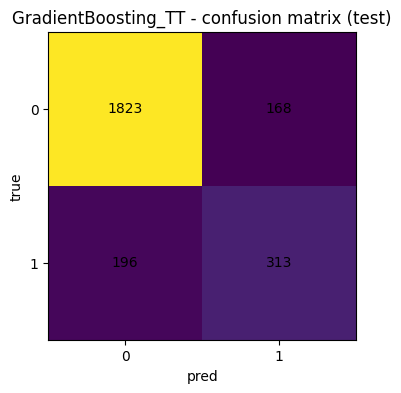

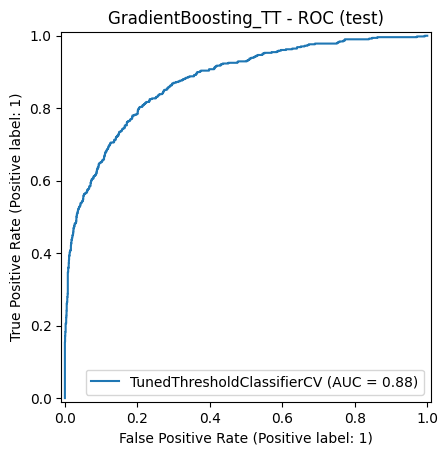

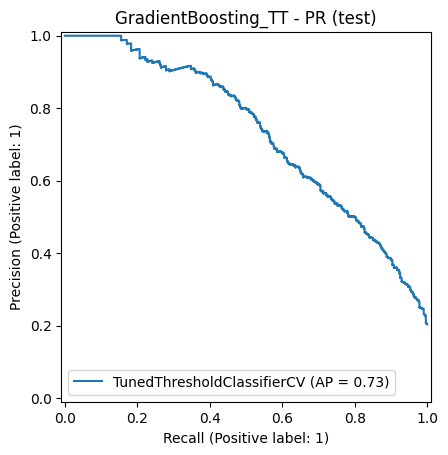

In [25]:
y_pred = best_model.predict(X_test)

plot_confusion(y_test,y_pred,title=f"{best_label} - confusion matrix (test)",path="artifacts/figures/best_model_confusion_matrix_test.png")
plot_roc(best_model,X_test,y_test,title=f"{best_label} - ROC (test)",path="artifacts/figures/best_model_ROC_test.png")
plot_pr(best_model,X_test,y_test,title=f"{best_label} - PR (test)",path="artifacts/figures/best_model_PR_test.png")

## Интерпретация

### Permutation importance(top-10)

Для топ модели по roc_auc посчитаем permutation_importance(top-10)

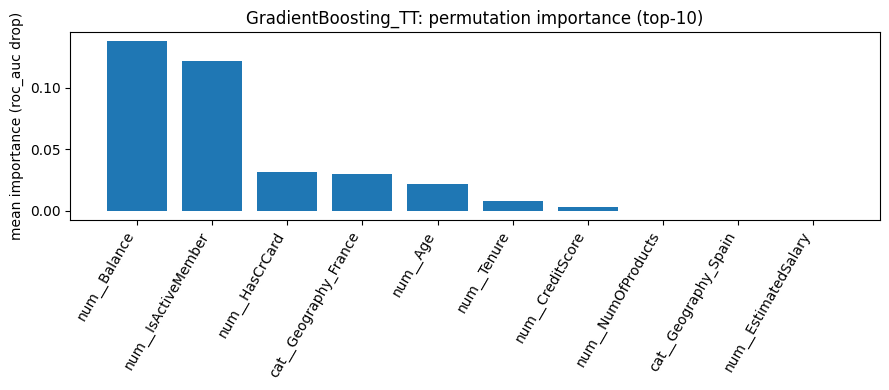

In [26]:
scoring = "roc_auc" if hasattr(best_model,"predict_proba") else "accuracy"


perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring=scoring
)

imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:10]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_label}: permutation importance (top-10)")
plt.tight_layout()
plt.show()

#### Интерпретация:
- В среднем наиболее полезные признаки для результатов оказались баланс и активность человека в банке, соответственно модель обнаружила сильную их связь с вероятностью ухода человека
- Следующим признаков идет наличие кредитной карты у человека, соответственно в теории если у человека есть долги по кредитке/кредитная карта с хорошим балансом/бонусы, то это больше удерживает человека в банке
- Модель решила, что значимым фактором служит проживает ли человек во Франции. Возможно, это особенность местного рынка или конкуренция в регионе
- По классике  среднюю важность занимает возраст, тк разного возраста клиенты имеют разные финансовые цели и разную склонность к банкам
- К низкой важности относятся срок клиента пользования банком и кредитная история - они почти никак не влияют на отток, признаки оказались почти неинформативными
- Все остальные признаки вообще не имеют важности для модели, они являются кандидатами на удаление

### SHAP

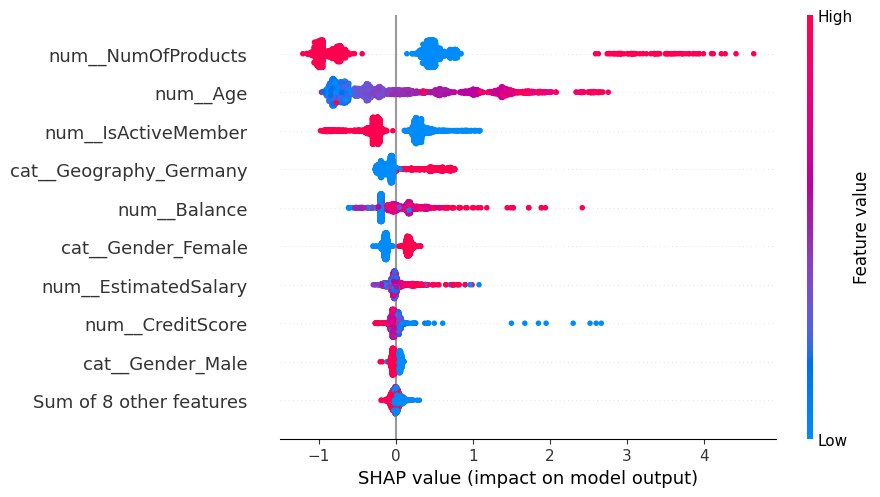

In [27]:
explainer = shap.TreeExplainer(best_model.estimator_.steps[-1][1])
X_test_transformed = best_model.estimator_.named_steps["preprocessor"].transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

shap_values = explainer(X_test_df) 
shap.plots.beeswarm(shap_values,show=False)
plt.savefig("artifacts/figures/best_model_SHAP.png",bbox_inches='tight')
plt.show()

#### Интерпретация (чем выше признак - тем больше играет роль в предсказании модели; если точки справа то они тянут прогноз вверх, и наоборот; если красные точки справа, а синие слева - зависимость прямая, соотвественно если наоборот, то зависимость обратная):
- Малое количество банковский продуктов в большинстве случаев сильно увеличивает вероятность оттока (для части клиентов это не так)
- Чем выше возраст, тем выше вероятность ухода
- По логике - если клиент активен то это сильно снижает вероятность ухода
- Клиенты из Германии имеют специфику высокого риска оттока
- Высокий баланс чаще сопровождает клиента к уходу (возможно, состоятельные клиенты переводят крупные суммы в другие банки)
- Женщины более склонны к оттоку, чем мужчины

## Сохранение лучшей модели и ее meta

In [28]:
model_path = artifactsPath / "best_model.joblib"
model_meta_path = artifactsPath / "best_model_meta.json"
joblib.dump(best_model,model_path)

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label.replace('_TT', ''), None),
    "random_state": RANDOM_STATE,
}

save_json(meta,model_meta_path)

print("Saved:", model_path)
print("Saved:", model_meta_path)

Saved: C:\Users\User\Documents\VSC\prediction_churn_bank-s_customer\notebooks\artifacts\best_model.joblib
Saved: C:\Users\User\Documents\VSC\prediction_churn_bank-s_customer\notebooks\artifacts\best_model_meta.json
